In [231]:
import os
import glob
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Configuration

In [232]:
DATA_PATH = "../emissions-data"

TARGET_COL = "Carbon intensity gCO₂eq/kWh (direct)"
FEATURES = [
    TARGET_COL,
    "diff_1",
    "diff_24",
    "hour_sin",
    "hour_cos",
    "year_sin",
    "year_cos",
    "Total_Wind",
    "SolarPower",
    # "Total_Exchange",
    "mean_wind_speed",
    # "mean_radiation",
    # "mean_temp",
    "DayAhead_Price"
]

WINDOW_SIZE = 336              # 14 days history
FORECAST_HORIZON = 24          # predict next 24 hours
LEARNING_RATE = 0.001
EPOCHS = 50
BATCH_SIZE = 32

LOG_DIR = "logs"
MODEL_DIR = "saved_model_cnn_v2"
TFLITE_PATH = "carbon_model_cnn_v2.tflite"

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# Load & Preprocess Data

## Carbon Emissions

In [233]:
csv_files = glob.glob(os.path.join(DATA_PATH, "*.csv"))
df = pd.concat((
    pd.read_csv(f, parse_dates=["Datetime (UTC)"]) for f in csv_files),
    ignore_index=True)
df = df.sort_values("Datetime (UTC)")

df["Datetime (UTC)"] = pd.to_datetime(df["Datetime (UTC)"], utc=True)

# Time features
df["hour"] = df["Datetime (UTC)"].dt.hour
df["day_of_year"] = df["Datetime (UTC)"].dt.dayofyear

# Cyclical encoding
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["year_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["year_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

# Differencing (SARIMA-like I component)
df["diff_1"] = df[TARGET_COL].diff(1)
df["diff_24"] = df[TARGET_COL].diff(24)

df = df.drop(columns=["Data estimated", "Country", "Zone name", "Data source", "Data estimation method"])
df = df.dropna().reset_index(drop=True)
df

,Datetime (UTC),Zone id,Carbon intensity gCO₂eq/kWh (direct),Carbon intensity gCO₂eq/kWh (Life cycle),Carbon-free energy percentage (CFE%),Renewable energy percentage (RE%),hour,day_of_year,hour_sin,hour_cos,year_sin,year_cos,diff_1,diff_24
0,2021-01-02 00:00:00+00:00,DK,138.00,216.92,79.46,65.58,0,2,0.000000,1.000000,3.442161e-02,0.999407,1.78,13.34
1,2021-01-02 01:00:00+00:00,DK,125.57,204.53,80.81,66.85,1,2,0.258819,0.965926,3.442161e-02,0.999407,-12.43,14.27
2,2021-01-02 02:00:00+00:00,DK,117.76,196.51,81.74,67.74,2,2,0.500000,0.866025,3.442161e-02,0.999407,-7.81,9.54
3,2021-01-02 03:00:00+00:00,DK,113.56,190.37,82.06,67.82,3,2,0.707107,0.707107,3.442161e-02,0.999407,-4.20,2.08
4,2021-01-02 04:00:00+00:00,DK,120.01,193.65,81.42,66.91,4,2,0.866025,0.500000,3.442161e-02,0.999407,6.45,1.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43795,2025-12-31 19:00:00+00:00,DK,103.88,170.66,85.19,80.95,19,365,-0.965926,0.258819,6.432491e-16,1.000000,-10.96,29.31
43796,2025-12-31 20:00:00+00:00,DK,106.39,170.86,84.76,80.49,20,365,-0.866025,0.500000,6.432491e-16,1.000000,2.51,38.71
43797,2025-12-31 21:00:00+00:00,DK,87.89,140.17,87.42,80.60,21,365,-0.707107,0.707107,6.432491e-16,1.000000,-18.50,22.69
43798,2025-12-31 22:00:00+00:00,DK,77.02,123.40,88.99,82.10,22,365,-0.500000,0.866025,6.432491e-16,1.000000,-10.87,6.27


## Electicity Production

In [234]:
elec_files = sorted(glob.glob("../electricity-prod/electricity_prod_*.csv"))
elec_dfs = [pd.read_csv(f, parse_dates=["Minutes5UTC"]) for f in elec_files]
elec = pd.concat(elec_dfs, ignore_index=True)

# Aggregate by timestamp (grouping DK1+DK2)
prod_cols = ["ProductionLt100MW", "ProductionGe100MW",
             "OffshoreWindPower", "OnshoreWindPower", "SolarPower"]
all_cols = prod_cols + ["ExchangeGreatBelt", "ExchangeGermany",
                        "ExchangeNetherlands", "ExchangeGreatBritain",
                        "ExchangeNorway", "ExchangeSweden"]
elec_agg = elec.groupby("Minutes5UTC")[all_cols].sum().reset_index()

# Resample to hourly
elec_agg.set_index("Minutes5UTC", inplace=True)
elec_hourly = elec_agg.resample("1h").mean().reset_index()
elec_hourly.rename(columns={"Minutes5UTC": "Datetime (UTC)"}, inplace=True)

elec_hourly["Datetime (UTC)"] = pd.to_datetime(elec_hourly["Datetime (UTC)"], utc=True)

# Create derived features
elec_hourly["Total_Wind"] = (
    elec_hourly["OnshoreWindPower"] +
    elec_hourly["OffshoreWindPower"]
)
elec_hourly["Total_Exchange"] = (
    elec_hourly["ExchangeGreatBelt"] +
    elec_hourly["ExchangeGermany"] +
    elec_hourly["ExchangeNetherlands"] +
    elec_hourly["ExchangeGreatBritain"] +
    elec_hourly["ExchangeNorway"] +
    elec_hourly["ExchangeSweden"]
)

print("Electricity production data shape:", elec_hourly.shape)
elec_hourly

Electricity production data shape: (45372, 14)


,Datetime (UTC),ProductionLt100MW,ProductionGe100MW,OffshoreWindPower,OnshoreWindPower,SolarPower,ExchangeGreatBelt,ExchangeGermany,ExchangeNetherlands,ExchangeGreatBritain,ExchangeNorway,ExchangeSweden,Total_Wind,Total_Exchange
0,2020-12-31 23:00:00+00:00,622.559170,1358.679163,311.905001,277.196667,0.000000,0.0,-2676.637517,0.360000,0.000000,1631.834188,1777.146667,589.101668,732.703338
1,2021-01-01 00:00:00+00:00,610.632501,1328.845009,257.105832,253.713335,0.000000,0.0,-2648.244168,0.360000,0.000000,1631.609172,1785.209167,510.819167,768.934171
2,2021-01-01 01:00:00+00:00,583.564171,1168.685839,243.176666,221.970834,0.000000,0.0,-2536.639160,0.360000,0.000000,1631.798330,1778.274160,465.147500,873.793330
3,2021-01-01 02:00:00+00:00,579.160830,1062.479996,208.182500,200.799167,0.000000,0.0,-2464.320012,0.360000,0.000000,1631.771678,1769.229157,408.981667,937.040822
4,2021-01-01 03:00:00+00:00,575.095001,1042.495005,177.857499,166.866667,0.000000,0.0,-2388.594152,0.360000,0.000000,1631.775838,1730.309998,344.724167,973.851684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45367,2026-03-06 06:00:00+00:00,670.730839,1044.744169,483.640834,669.595843,132.431665,0.0,-1127.696680,120.454165,1099.239990,1481.453349,710.141659,1153.236677,2283.592482
45368,2026-03-06 07:00:00+00:00,604.282500,1012.554164,510.496665,602.752506,727.238333,0.0,606.453325,28.391664,239.592500,877.711662,311.265006,1113.249171,2063.414156
45369,2026-03-06 08:00:00+00:00,531.902501,962.986664,538.920832,410.207501,1792.005007,0.0,2565.695831,-71.064169,-932.304184,-287.517500,159.133332,949.128334,1433.943310
45370,2026-03-06 09:00:00+00:00,454.290836,837.362496,552.527498,198.117500,2562.585826,0.0,2525.207479,141.719166,-999.436687,-973.000000,333.449159,750.644997,1027.939118


## Weather Data (Wind, Solar, Temperature)

In [235]:
# Load wind speed
wind_path = "../weather"
wind_files = sorted(glob.glob(os.path.join(wind_path, "*dmi_wind.csv")))
if wind_files:
    wind_dfs = []
    for f in wind_files:
        try:
            df_wind = pd.read_csv(f)
            df_wind["timeObserved"] = pd.to_datetime(df_wind["timeObserved"], format='ISO8601')
            # Remove calibration entries
            df_wind = df_wind[df_wind["timeObserved"].dt.microsecond == 0]
            wind_dfs.append(df_wind)
        except Exception as e:
            print(f"  Warning loading {f}: {e}")

    if wind_dfs:
        wind_df = pd.concat(wind_dfs, ignore_index=True)
        wind_df = wind_df.sort_values("timeObserved")

        # Aggregate ALL stations to hourly mean (not individual)
        wind_hourly = wind_df.groupby(
            pd.Grouper(key="timeObserved", freq="h")
        ).agg({
            "mean_wind_speed": "mean",
            "stationId": "nunique"  # Count unique stations
        }).reset_index()

        wind_hourly = wind_hourly.rename(columns={
            "timeObserved": "Datetime (UTC)",
            "stationId": "wind_station_count"
        })

        # Only keep hours with at least 3 stations (quality filter)
        wind_hourly = wind_hourly[wind_hourly["wind_station_count"] >= 3]
        wind_hourly = wind_hourly.drop(columns=["wind_station_count"])

        print(f"Wind speed: {len(wind_hourly)} hourly records from multi-station average")
    else:
        wind_hourly = None
else:
    print("Warning: No wind speed data found")
    wind_hourly = None

# Load solar radiation
solar_files = sorted(glob.glob(os.path.join(wind_path, "*dmi_sun.csv")))
if solar_files:
    solar_dfs = []
    for f in solar_files:
        try:
            df_solar = pd.read_csv(f)
            df_solar["timeObserved"] = pd.to_datetime(df_solar["timeObserved"], format='ISO8601')
            df_solar = df_solar[df_solar["timeObserved"].dt.microsecond == 0]
            solar_dfs.append(df_solar)
        except Exception as e:
            print(f"  Warning loading {f}: {e}")

    if solar_dfs:
        solar_df = pd.concat(solar_dfs, ignore_index=True)
        solar_df = solar_df.sort_values("timeObserved")

        solar_hourly = solar_df.groupby(
            pd.Grouper(key="timeObserved", freq="h")
        ).agg({
            "mean_radiation": "mean",
            "stationId": "nunique"
        }).reset_index()

        solar_hourly = solar_hourly.rename(columns={
            "timeObserved": "Datetime (UTC)",
            "stationId": "solar_station_count"
        })

        solar_hourly = solar_hourly[solar_hourly["solar_station_count"] >= 3]
        solar_hourly = solar_hourly.drop(columns=["solar_station_count"])

        print(f"Solar radiation: {len(solar_hourly)} hourly records from multi-station average")
    else:
        solar_hourly = None
else:
    print("Warning: No solar radiation data found")
    solar_hourly = None

# Load temperature
temp_files = sorted(glob.glob(os.path.join(wind_path, "*dmi_temp.csv")))
if temp_files:
    temp_dfs = []
    for f in temp_files:
        try:
            df_temp = pd.read_csv(f)
            df_temp["timeObserved"] = pd.to_datetime(df_temp["timeObserved"], format='ISO8601')
            df_temp = df_temp[df_temp["timeObserved"].dt.microsecond == 0]
            temp_dfs.append(df_temp)
        except Exception as e:
            print(f"  Warning loading {f}: {e}")

    if temp_dfs:
        temp_df = pd.concat(temp_dfs, ignore_index=True)
        temp_df = temp_df.sort_values("timeObserved")

        temp_hourly = temp_df.groupby(
            pd.Grouper(key="timeObserved", freq="h")
        ).agg({
            "mean_temp": "mean",
            "stationId": "nunique"
        }).reset_index()

        temp_hourly = temp_hourly.rename(columns={
            "timeObserved": "Datetime (UTC)",
            "stationId": "temp_station_count"
        })

        temp_hourly = temp_hourly[temp_hourly["temp_station_count"] >= 3]
        temp_hourly = temp_hourly.drop(columns=["temp_station_count"])

        print(f"Temperature: {len(temp_hourly)} hourly records from multi-station average")
    else:
        temp_hourly = None
else:
    print("Warning: No temperature data found")
    temp_hourly = None


Wind speed: 52609 hourly records from multi-station average
Solar radiation: 52594 hourly records from multi-station average
Temperature: 52609 hourly records from multi-station average


In [236]:
price_files = sorted(glob.glob("../prices/DayAheadPrices*.csv"))  # Adjust path if needed
if price_files:
    price_dfs = [pd.read_csv(f, parse_dates=["MTU (UTC)"]) for f in price_files]
    prices = pd.concat(price_dfs, ignore_index=True)

    # Handle the MTU column (format: "start - end")
    prices["Datetime (UTC)"] = prices["MTU (UTC)"].str.split(" - ").str[0]
    prices["Datetime (UTC)"] = pd.to_datetime(prices["Datetime (UTC)"], utc=True)

    # Average price across areas/sequences
    price_hourly = prices.groupby("Datetime (UTC)")[
        "Day-ahead Price (EUR/MWh)"
    ].mean().reset_index()

    price_hourly.rename(columns={
        "Day-ahead Price (EUR/MWh)": "DayAhead_Price"
    }, inplace=True)

    print(f"Day-ahead prices: {len(price_hourly)} hourly records")
else:
    print("Warning: No price data found")
    price_hourly = None

Day-ahead prices: 41303 hourly records


C:\Users\jbro9\AppData\Local\Temp\ipykernel_27284\2036136459.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  price_dfs = [pd.read_csv(f, parse_dates=["MTU (UTC)"]) for f in price_files]
C:\Users\jbro9\AppData\Local\Temp\ipykernel_27284\2036136459.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  price_dfs = [pd.read_csv(f, parse_dates=["MTU (UTC)"]) for f in price_files]
C:\Users\jbro9\AppData\Local\Temp\ipykernel_27284\2036136459.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  price_dfs = [pd.read_csv(f, parse_dates=["MTU (UTC)"]) for f in price_files]
C:\Users\j

# Merge all datasets on "Datetime (UTC)"

In [237]:
# Start with emissions data
df_merged = df.copy()

# Merge electricity production
df_merged = df_merged.merge(
    elec_hourly,
    on="Datetime (UTC)",
    how="left"
)

# Merge weather data
if wind_hourly is not None:
    df_merged = df_merged.merge(
        wind_hourly,
        on="Datetime (UTC)",
        how="left"
    )

if solar_hourly is not None:
    df_merged = df_merged.merge(
        solar_hourly,
        on="Datetime (UTC)",
        how="left"
    )

if temp_hourly is not None:
    df_merged = df_merged.merge(
        temp_hourly,
        on="Datetime (UTC)",
        how="left"
    )

if price_hourly is not None:
    df_merged = df_merged.merge(
        price_hourly,
        on="Datetime (UTC)",
        how="left"
    )

# Use interpolation instead of forward fill (better for weather data)
numeric_cols = df_merged.select_dtypes(include=[np.number]).columns
df_merged[numeric_cols] = df_merged[numeric_cols].interpolate(method='linear', limit_direction='both')

df = df_merged.sort_values("Datetime (UTC)").reset_index(drop=True)

print("Merged data shape:", df.shape)
print("Columns:", df.columns.tolist())

# Check data quality
print("\nMissing values:")
print(df[FEATURES].isnull().sum())

Merged data shape: (43800, 31)
Columns: ['Datetime (UTC)', 'Zone id', 'Carbon intensity gCO₂eq/kWh (direct)', 'Carbon intensity gCO₂eq/kWh (Life cycle)', 'Carbon-free energy percentage (CFE%)', 'Renewable energy percentage (RE%)', 'hour', 'day_of_year', 'hour_sin', 'hour_cos', 'year_sin', 'year_cos', 'diff_1', 'diff_24', 'ProductionLt100MW', 'ProductionGe100MW', 'OffshoreWindPower', 'OnshoreWindPower', 'SolarPower', 'ExchangeGreatBelt', 'ExchangeGermany', 'ExchangeNetherlands', 'ExchangeGreatBritain', 'ExchangeNorway', 'ExchangeSweden', 'Total_Wind', 'Total_Exchange', 'mean_wind_speed', 'mean_radiation', 'mean_temp', 'DayAhead_Price']

Missing values:
Carbon intensity gCO₂eq/kWh (direct)    0
diff_1                                  0
diff_24                                 0
hour_sin                                0
hour_cos                                0
year_sin                                0
year_cos                                0
Total_Wind                              0
Sola

# DIAGNOSTIC: Feature Importance & Quality Analysis

In [238]:
print("=== FEATURE QUALITY ANALYSIS ===\n")

# 1. Check correlations with target
print("1. FEATURE CORRELATIONS WITH TARGET:")
correlations = df[FEATURES].corr()[TARGET_COL].sort_values(ascending=False)
print(correlations)
print()

# 2. Check for data coverage (non-missing values)
print("2. DATA COVERAGE:")
for col in FEATURES:
    missing_pct = (df[col].isnull().sum() / len(df)) * 100
    print(f"  {col}: {100-missing_pct:.1f}% coverage")
print()

# 3. Check feature variance (low variance = low signal)
print("3. FEATURE VARIANCE (normalized):")
from sklearn.preprocessing import StandardScaler
scaler_test = StandardScaler()
scaled = scaler_test.fit_transform(df[FEATURES].fillna(0))
variances = np.var(scaled, axis=0)
for feat, var in zip(FEATURES, variances):
    print(f"  {feat}: {var:.4f}")
print()

# 4. Check for redundancy (multicollinearity)
print("4. CORRELATION MATRIX (new features with existing):")
corr_matrix = df[FEATURES].corr()
print(corr_matrix)

=== FEATURE QUALITY ANALYSIS ===

1. FEATURE CORRELATIONS WITH TARGET:
Carbon intensity gCO₂eq/kWh (direct)    1.000000
diff_24                                 0.374849
year_cos                                0.363734
DayAhead_Price                          0.346547
diff_1                                  0.114735
year_sin                                0.102878
hour_sin                               -0.014681
hour_cos                               -0.039882
SolarPower                             -0.254867
mean_wind_speed                        -0.347039
Total_Wind                             -0.379890
Name: Carbon intensity gCO₂eq/kWh (direct), dtype: float64

2. DATA COVERAGE:
  Carbon intensity gCO₂eq/kWh (direct): 100.0% coverage
  diff_1: 100.0% coverage
  diff_24: 100.0% coverage
  hour_sin: 100.0% coverage
  hour_cos: 100.0% coverage
  year_sin: 100.0% coverage
  year_cos: 100.0% coverage
  Total_Wind: 100.0% coverage
  SolarPower: 100.0% coverage
  mean_wind_speed: 100.0% cover

# Split Data

In [239]:
train = df[(df["Datetime (UTC)"].dt.year >= 2021) &
           (df["Datetime (UTC)"].dt.year <= 2023)]

val = df[df["Datetime (UTC)"].dt.year == 2024]
test = df[df["Datetime (UTC)"].dt.year == 2025]

# Normalization

In [240]:
feature_cols = [col for col in FEATURES if col != TARGET_COL]

feature_scaler = StandardScaler()
target_scaler = StandardScaler()

# Fit and transform features
train_features_scaled = feature_scaler.fit_transform(train[feature_cols])
val_features_scaled = feature_scaler.transform(val[feature_cols])
test_features_scaled = feature_scaler.transform(test[feature_cols])

# Fit and transform target
train_target_scaled = target_scaler.fit_transform(train[[TARGET_COL]])
val_target_scaled = target_scaler.transform(val[[TARGET_COL]])
test_target_scaled = target_scaler.transform(test[[TARGET_COL]])

# Update dataframes
train[feature_cols] = train_features_scaled
val[feature_cols] = val_features_scaled
test[feature_cols] = test_features_scaled

train[TARGET_COL] = train_target_scaled
val[TARGET_COL] = val_target_scaled
test[TARGET_COL] = test_target_scaled

# Save scaler parameters
scaler_params = {
    "target_mean": target_scaler.mean_.tolist(),
    "target_scale": target_scaler.scale_.tolist(),
    "feature_mean": feature_scaler.mean_.tolist(),
    "feature_scale": feature_scaler.scale_.tolist(),
    "feature_names": feature_cols
}

with open("scaler_params_cnn_v2.json", "w") as f:
    json.dump(scaler_params, f, indent=4)

# Feature Selection

In [241]:
def create_dataset(data):
    x, y = [], []
    values = data[FEATURES].values
    target = data[TARGET_COL].values

    for i in range(WINDOW_SIZE, len(data) - FORECAST_HORIZON):
        x.append(values[i-WINDOW_SIZE:i])
        y.append(target[i:i+FORECAST_HORIZON])

    return np.array(x), np.array(y)

x_train, y_train = create_dataset(train)
x_val, y_val = create_dataset(val)
x_test, y_test = create_dataset(test)

print("Train shape:", x_train.shape)
print("Val shape:", x_val.shape)
print("Test shape:", x_test.shape)

Train shape: (25896, 336, 11)
Val shape: (8424, 336, 11)
Test shape: (8400, 336, 11)


# Build SARIMA-like Model

In [242]:
num_features = len(FEATURES)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW_SIZE, num_features)),

    # Linear convolution → AR-like behavior
    tf.keras.layers.Conv1D(32, kernel_size=3, activation="linear"),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation="linear"),
    tf.keras.layers.Dense(FORECAST_HORIZON)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 334, 32)        │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 10688)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │       684,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 686,744 (2.62 MB)

 Trainable params: 686,744 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

# Callbacks

In [243]:
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=LOG_DIR)

csv_logger = tf.keras.callbacks.CSVLogger("training_log_cnn_v2.csv")

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(MODEL_DIR, "best_model.keras"),
    monitor="val_loss",
    save_best_only=True
)

# Train

In [244]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[tensorboard_cb, csv_logger, early_stop, checkpoint]
)

Epoch 1/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5509 - mae: 0.5202 - val_loss: 0.2581 - val_mae: 0.3825
Epoch 2/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3228 - mae: 0.4221 - val_loss: 0.2433 - val_mae: 0.3730
Epoch 3/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3149 - mae: 0.4158 - val_loss: 0.2413 - val_mae: 0.3683
Epoch 4/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3114 - mae: 0.4138 - val_loss: 0.2463 - val_mae: 0.3725
Epoch 5/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3097 - mae: 0.4125 - val_loss: 0.2406 - val_mae: 0.3636
Epoch 6/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3095 - mae: 0.4120 - val_loss: 0.2432 - val_mae: 0.3675
Epoch 7/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3090 - mae: 0.4114 - val_loss: 0.2579 - val_mae: 0.3861
Epoch 8/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3092 - mae: 0.4109 - val_loss: 0.2498 - val_mae: 0.3756
Epoch 9/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - lo

# Evaluate

In [245]:
y_pred_scaled = model.predict(x_test)

# Convert back to real carbon intensity
y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = target_scaler.inverse_transform(y_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)

print("Real-world MAE:", mae)
print("Real-world MSE:", mse)

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Real-world MAE: 20.454041411338576
Real-world MSE: 721.0051548871285


# Save Model

In [246]:
model.save(os.path.join(MODEL_DIR, "final_model.keras"))

# Convert to TFLite

In [247]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

print("TFLite model saved:", TFLITE_PATH)

INFO:tensorflow:Assets written to: C:\Users\jbro9\AppData\Local\Temp\tmp84qkpzyt\assets


INFO:tensorflow:Assets written to: C:\Users\jbro9\AppData\Local\Temp\tmp84qkpzyt\assets


Saved artifact at 'C:\Users\jbro9\AppData\Local\Temp\tmp84qkpzyt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 336, 11), dtype=tf.float32, name='keras_tensor_40')
Output Type:
  TensorSpec(shape=(None, 24), dtype=tf.float32, name=None)
Captures:
  2169938627472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169872194960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169872198032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169872202832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169293156816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2169293144336: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model saved: carbon_model_cnn_v2.tflite


# Save Hyperparameters

In [248]:
params = {
    "window_size": WINDOW_SIZE,
    "forecast_horizon": FORECAST_HORIZON,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "features": FEATURES
}

with open("model_params.json", "w") as f:
    json.dump(params, f, indent=4)

print("Training complete.")

Training complete.


# One Random 24h Forecast

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


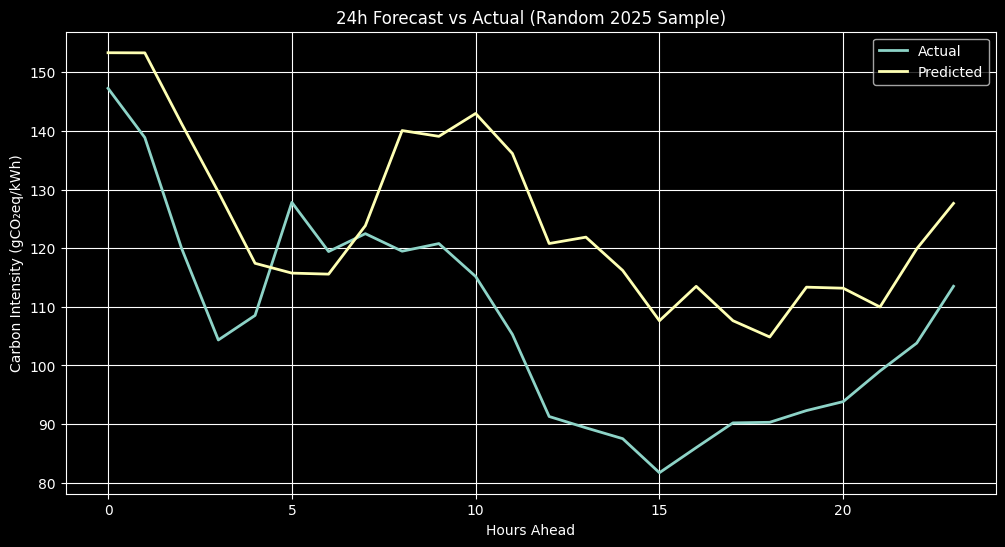

In [249]:
# Pick random test sample
idx = np.random.randint(0, len(x_test))

input_sample = x_test[idx:idx+1]
true_future_scaled = y_test[idx]

# Predict
pred_scaled = model.predict(input_sample)[0]

# Inverse scale
true_future = target_scaler.inverse_transform(
    true_future_scaled.reshape(-1, 1)
).flatten()

pred_future = target_scaler.inverse_transform(
    pred_scaled.reshape(-1, 1)
).flatten()

# Plot
plt.figure(figsize=(12, 6))
hours = np.arange(FORECAST_HORIZON)

plt.plot(hours, true_future, label="Actual", linewidth=2)
plt.plot(hours, pred_future, label="Predicted", linewidth=2)

plt.title("24h Forecast vs Actual (Random 2025 Sample)")
plt.xlabel("Hours Ahead")
plt.ylabel("Carbon Intensity (gCO₂eq/kWh)")
plt.legend()
plt.grid(True)
plt.show()

# Best 3-Hour Charging Window

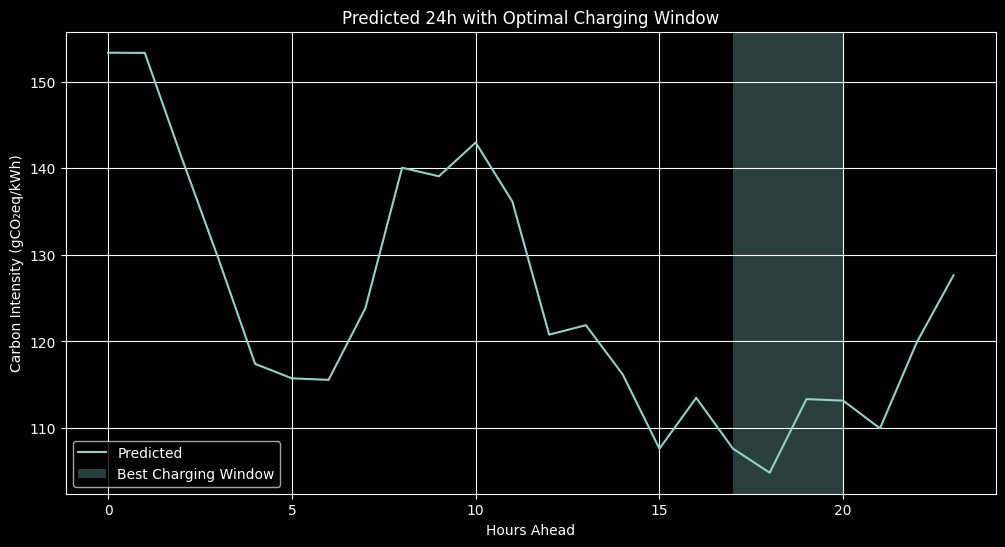

Best charging window: hour 17 to 20


In [250]:
window_size = 3

rolling_avg = np.convolve(
    pred_future,
    np.ones(window_size) / window_size,
    mode='valid'
)

best_start = np.argmin(rolling_avg)
best_end = best_start + window_size

plt.figure(figsize=(12, 6))
plt.plot(hours, pred_future, label="Predicted")

plt.axvspan(best_start, best_end,
            alpha=0.3,
            label="Best Charging Window")

plt.title("Predicted 24h with Optimal Charging Window")
plt.xlabel("Hours Ahead")
plt.ylabel("Carbon Intensity (gCO₂eq/kWh)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best charging window: hour {best_start} to {best_end}")

# Evaluate Error Per Forecast Hour

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step


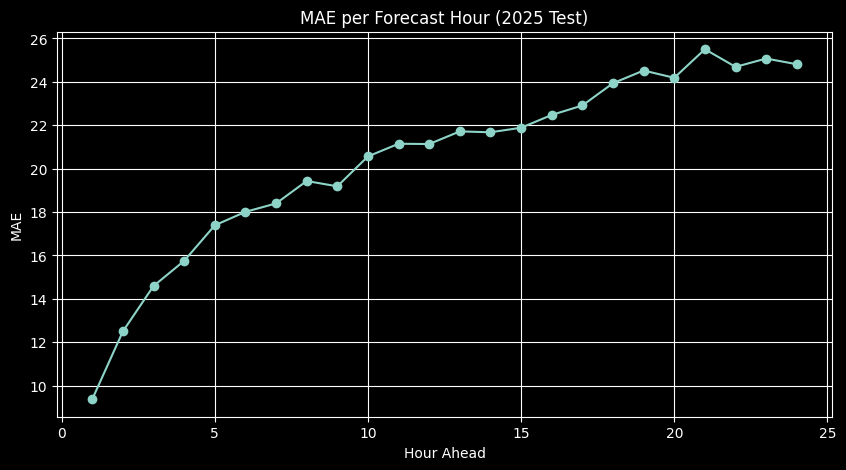

In [251]:
# Predict entire test set
pred_all_scaled = model.predict(x_test)

# Inverse scale
pred_all = target_scaler.inverse_transform(
    pred_all_scaled.reshape(-1, 1)
).reshape(-1, FORECAST_HORIZON)

true_all = target_scaler.inverse_transform(
    y_test.reshape(-1, 1)
).reshape(-1, FORECAST_HORIZON)

# Compute MAE per forecast hour
mae_per_hour = np.mean(np.abs(pred_all - true_all), axis=0)

plt.figure(figsize=(10, 5))
plt.plot(range(1, FORECAST_HORIZON+1), mae_per_hour, marker='o')
plt.title("MAE per Forecast Hour (2025 Test)")
plt.xlabel("Hour Ahead")
plt.ylabel("MAE")
plt.grid(True)
plt.show()

# Full 24h Forecast Distribution

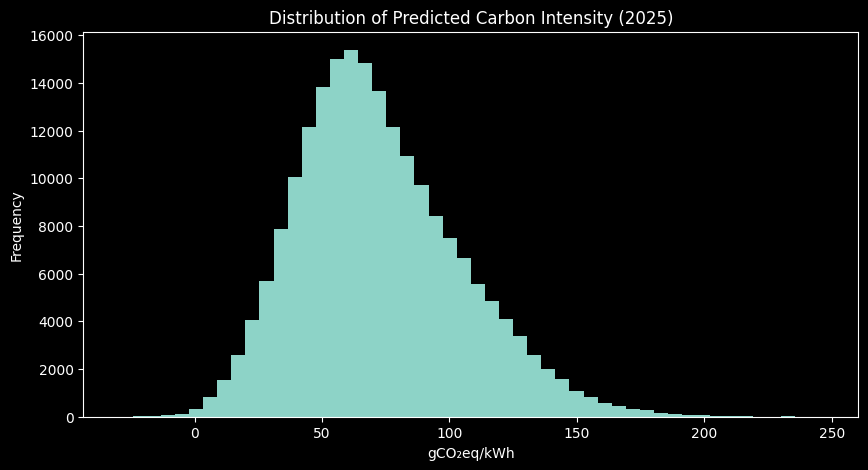

In [252]:
plt.figure(figsize=(10, 5))
plt.hist(pred_all.flatten(), bins=50)
plt.title("Distribution of Predicted Carbon Intensity (2025)")
plt.xlabel("gCO₂eq/kWh")
plt.ylabel("Frequency")
plt.show()

# Summer vs Winter Performance

In [253]:
test_dates = test.iloc[WINDOW_SIZE:len(test)-FORECAST_HORIZON]["Datetime (UTC)"]

summer_mask = test_dates.dt.month.isin([6,7,8])
winter_mask = test_dates.dt.month.isin([12,1,2])

summer_mae = np.mean(np.abs(
    pred_all[summer_mask.values] -
    true_all[summer_mask.values]
))

winter_mae = np.mean(np.abs(
    pred_all[winter_mask.values] -
    true_all[winter_mask.values]
))

print("Summer MAE:", summer_mae)
print("Winter MAE:", winter_mae)

Summer MAE: 18.308196280135046
Winter MAE: 20.93993017938049
